# Implied Volatility Surface

Constructing an implied vol surface from synthetic option prices using Newton-Raphson inversion of the Black-Scholes formula.

In [7]:
import sys
sys.path.append('../src')

import numpy as np
import matplotlib.pyplot as plt
from black_scholes import black_scholes_call
from implied_vol import implied_vol

In [8]:
S0 = 100.0
r = 0.05

strikes = np.linspace(80, 120, 30)
maturities = np.linspace(0.1, 2.0, 20)
K_grid, T_grid = np.meshgrid(strikes, maturities)

# Synthetic vol surface: smile + term structure
true_vol_surface = 0.2 + 0.1 * (K_grid / S0 - 1)**2 + 0.05 / T_grid

# Generate synthetic market prices from this surface
market_prices = np.zeros_like(K_grid)
for i in range(K_grid.shape[0]):
    for j in range(K_grid.shape[1]):
        market_prices[i, j] = black_scholes_call(S0, K_grid[i, j], r, true_vol_surface[i, j], T_grid[i, j])

In [9]:
recovered_vol = np.zeros_like(K_grid)
for i in range(K_grid.shape[0]):
    for j in range(K_grid.shape[1]):
        recovered_vol[i, j] = implied_vol(market_prices[i, j], S0, K_grid[i, j], r, T_grid[i, j])

max_error = np.nanmax(np.abs(recovered_vol - true_vol_surface))
print(f"Max recovery error: {max_error:.2e}")

Max recovery error: 1.94e-15


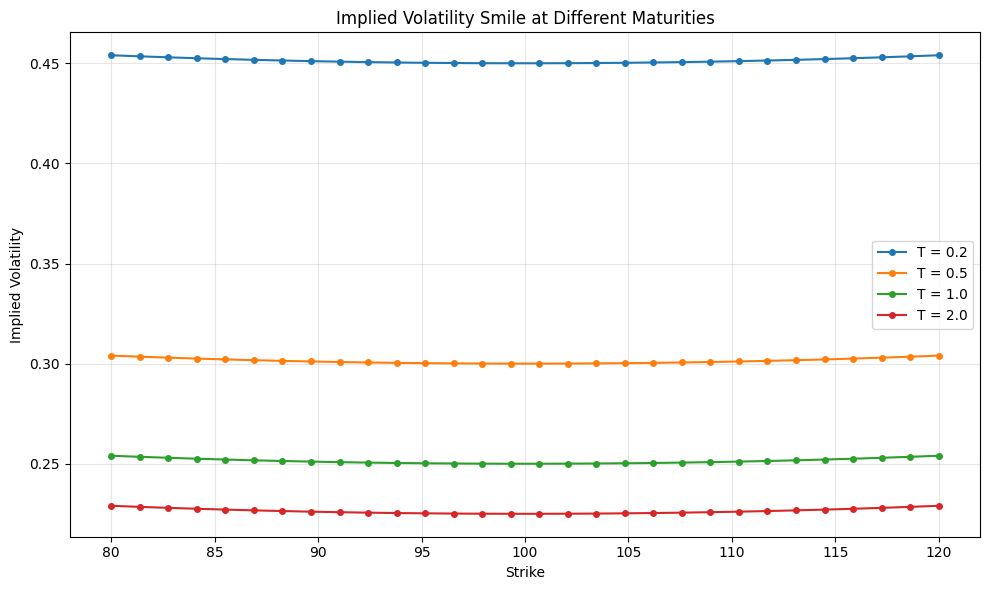

In [10]:
plt.figure(figsize=(10, 6))
for T in [0.2, 0.5, 1.0, 2.0]:
    idx = np.argmin(np.abs(maturities - T))
    plt.plot(strikes, recovered_vol[idx, :], 'o-', markersize=4, label=f'T = {maturities[idx]:.1f}')

plt.xlabel('Strike')
plt.ylabel('Implied Volatility')
plt.title('Implied Volatility Smile at Different Maturities')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../figures/vol_smile.png', dpi=300)
plt.show()

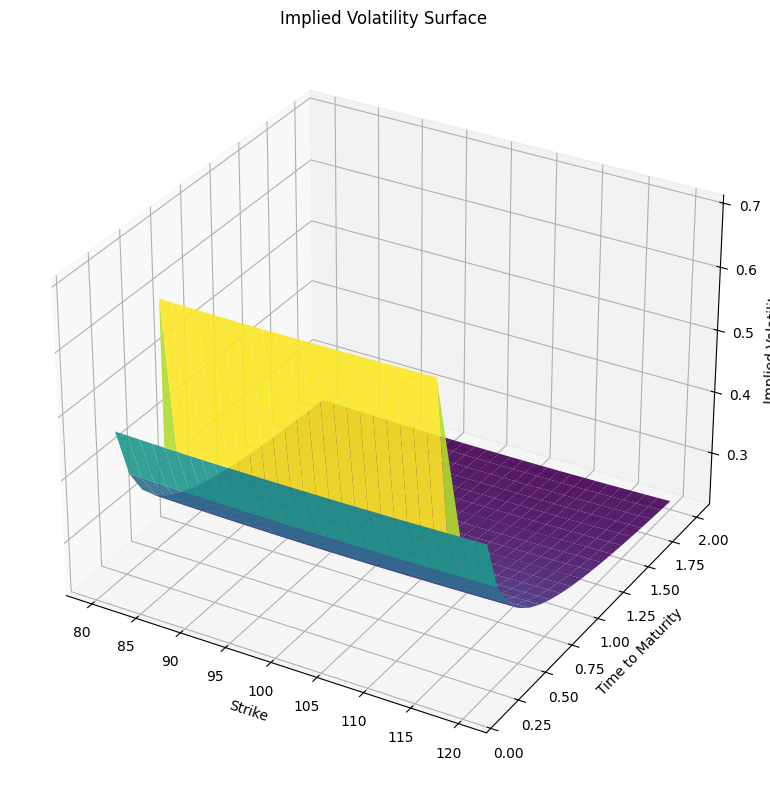

In [12]:
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(K_grid, T_grid, recovered_vol, cmap='viridis', alpha=0.9)
ax.set_xlabel('Strike')
ax.set_ylabel('Time to Maturity')
ax.set_zlabel('Implied Volatility')
ax.set_title('Implied Volatility Surface')
plt.tight_layout()
plt.savefig('../figures/implied_vol_surface.png', dpi=300)
plt.show()

In [ ]:
# Track convergence for one option
S0_test, K_test, r_test, T_test = 100, 100, 0.05, 1.0
true_sigma = 0.3
market_price = black_scholes_call(S0_test, K_test, r_test, true_sigma, T_test)

sigma = 0.2
errors = []

for _ in range(15):
    from implied_vol import bs_price, bs_vega
    price = bs_price(S0_test, K_test, r_test, sigma, T_test)
    v = bs_vega(S0_test, K_test, r_test, sigma, T_test)
    errors.append(abs(sigma - true_sigma))
    sigma = sigma - (price - market_price) / v

plt.figure(figsize=(10, 6))
plt.semilogy(range(len(errors)), errors, 'o-')
plt.xlabel('Iteration')
plt.ylabel('|sigma_n - sigma*|')
plt.title('Newton-Raphson Convergence (Quadratic)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../figures/newton_raphson_convergence.png', dpi=300)
plt.show()